## Import libraries


In [2]:
# Core Python
import os
import time
import random
import math
import warnings
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

# Extra pretrained models (e.g., InceptionResNetV2, Xception)
import timm

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Hyperparameter optimization
from hyperopt import hp, fmin, tpe, rand, STATUS_OK, Trials

# Suppress warnings
warnings.filterwarnings("ignore")

# Reproducibility (optional but recommended)
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

## PyTorch GPU Sanity Check


In [3]:
# Check for GPU availability and show device info
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print(f"✅ GPU is available: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"Device Count: {torch.cuda.device_count()}")
else:
    print("⚠️ GPU not available. Using CPU instead.")

# Set default tensor type (optional, if you want to default to GPU when available)
# torch.set_default_tensor_type(torch.FloatTensor if device.type == 'cpu' else torch.cuda.FloatTensor)

✅ GPU is available: NVIDIA GeForce RTX 3060
CUDA Version: 12.8
Device Count: 1


## Global DEMO Configuration


In [4]:
# Global Demo Config
DEMO_MODE = True  # Toggle this to False when running full training
DEMO_EPOCHS = 3
DEMO_BATCHSIZE = 16
DEMO_SAMPLE_SIZE = 128  # Number of images per split (train/test) in demo mode

## Generate Training and Test Images


In [5]:
# Constants
TARGET_SIZE = (224, 224)
INPUT_SIZE = (3, 224, 224)  # PyTorch uses CHW format
BATCHSIZE = 32  # 128 or 32

# Define image transformations
transform = transforms.Compose(
    [
        transforms.Resize(TARGET_SIZE),
        transforms.ToTensor(),
    ]
)

train_dataset = datasets.ImageFolder(root="./train_224/", transform=transform)
test_dataset = datasets.ImageFolder(root="./test_224/", transform=transform)

if DEMO_MODE:
    train_dataset = torch.utils.data.Subset(train_dataset, range(DEMO_SAMPLE_SIZE))
    test_dataset = torch.utils.data.Subset(test_dataset, range(DEMO_SAMPLE_SIZE))
    BATCHSIZE = DEMO_BATCHSIZE
else:
    BATCHSIZE = 32

train_loader = DataLoader(
    train_dataset, batch_size=BATCHSIZE, shuffle=True, num_workers=2
)
validation_loader = DataLoader(
    test_dataset, batch_size=BATCHSIZE, shuffle=False, num_workers=2
)

num_classes = len(train_dataset.dataset.classes if DEMO_MODE else train_dataset.classes)

### Define the image plotting functions


In [23]:
class LossHistory:
    def __init__(self):
        self.losses = {"batch": [], "epoch": []}
        self.accuracy = {"batch": [], "epoch": []}
        self.val_loss = {"batch": [], "epoch": []}
        self.val_acc = {"batch": [], "epoch": []}

    def record_batch(self, train_loss, train_acc, val_loss=None, val_acc=None):
        self.losses["batch"].append(train_loss)
        self.accuracy["batch"].append(train_acc)
        if val_loss is not None:
            self.val_loss["batch"].append(val_loss)
        if val_acc is not None:
            self.val_acc["batch"].append(val_acc)

    def record_epoch(self, train_loss, train_acc, val_loss, val_acc):
        self.losses["epoch"].append(train_loss)
        self.accuracy["epoch"].append(train_acc)
        self.val_loss["epoch"].append(val_loss)
        self.val_acc["epoch"].append(val_acc)

    def loss_plot(self, loss_type="epoch"):
        iters = range(len(self.losses[loss_type]))
        plt.figure()
        plt.plot(iters, self.losses[loss_type], "g", label="train loss")
        if loss_type == "epoch":
            plt.plot(iters, self.accuracy[loss_type], "r", label="train acc")
            plt.plot(iters, self.val_acc[loss_type], "b", label="val acc")
            plt.plot(iters, self.val_loss[loss_type], "k", label="val loss")
        plt.grid(True)
        plt.xlabel(loss_type)
        plt.ylabel("acc-loss")
        plt.legend(loc="upper right")
        plt.show()

    def plot(self):
        self.loss_plot("epoch")

In [24]:
# Instantiate tracker
history_this = LossHistory()

# Construct CNN models


### Model 1: a CNN model by own (baseline)


#### Defining Model Architecture


In [8]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(CustomCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),  # input: (3,224,224)
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),  # output: (64,112,112)
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),  # output: (128,56,56)
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
        )

        self.global_pool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )  # Replaces GlobalAveragePooling2D
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x

#### Training Function


In [9]:
def train_model(
    model,
    train_loader,
    val_loader,
    num_classes,
    epochs=1,
    save_path="./artifacts/model_own.pth",
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct / total

        # Validation
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / val_total

        history_this.record_epoch(train_loss, train_acc, val_loss, val_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] - "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)

    print(f"Best Validation Accuracy: {best_val_acc:.4f}")

Epoch [1/1] - Train Loss: 0.1437, Train Acc: 0.9483 | Val Loss: 0.0250, Val Acc: 0.9937
Best Validation Accuracy: 0.9937


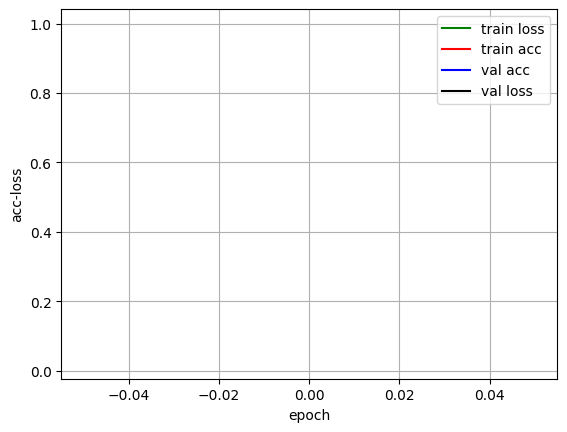

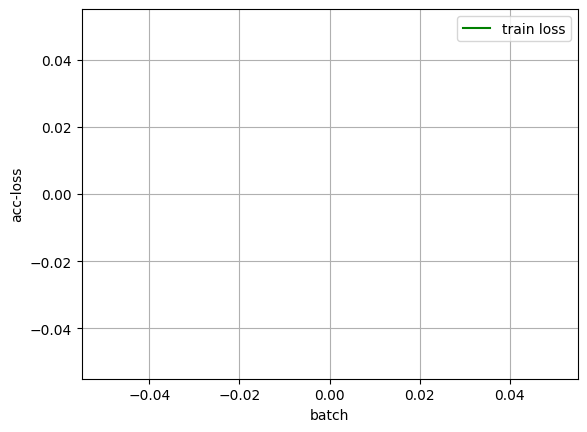

In [10]:
model = CustomCNN(num_classes=5)
train_model(
    model,
    train_loader,
    validation_loader,
    num_classes=5,
    epochs=1,
    save_path="./artifacts/model_own.pth",
)

# Plot results
history_this.loss_plot("epoch")
history_this.loss_plot("batch")  # If you also log batch-level metrics
plt.show()

Validation accuracy of a CNN by own: 99.884%


### Model 2: Xception


In [10]:
def train_xception(
    num_classes,
    train_loader,
    val_loader,
    epochs=1,
    save_path="./artifacts/xception.pth",
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load pretrained Xception from timm
    model_fine_tune = timm.create_model("xception", pretrained=True)

    # Freeze first 131 layers (approximate: timm models use named children instead of index)
    freeze_until = 131
    children = list(model_fine_tune.children())
    count = 0
    for child in children:
        count += 1
        if count < freeze_until:
            for param in child.parameters():
                param.requires_grad = False

    # Replace classification head
    model_fine_tune.reset_classifier(num_classes)

    model = model_fine_tune.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= len(train_loader.dataset)
        train_acc = correct / total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / val_total

        history_this.record_epoch(train_loss, train_acc, val_loss, val_acc)

        print(
            f"[{epoch+1}/{epochs}] Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}"
        )

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)

    print(f"Best Validation Accuracy: {best_val_acc:.4f}")

[1/1] Train Loss: 0.0687, Acc: 0.9855 | Val Loss: 0.0020, Acc: 0.9997
Best Validation Accuracy: 0.9997


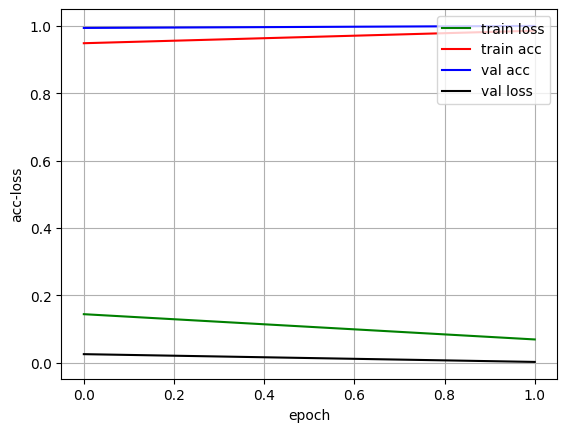

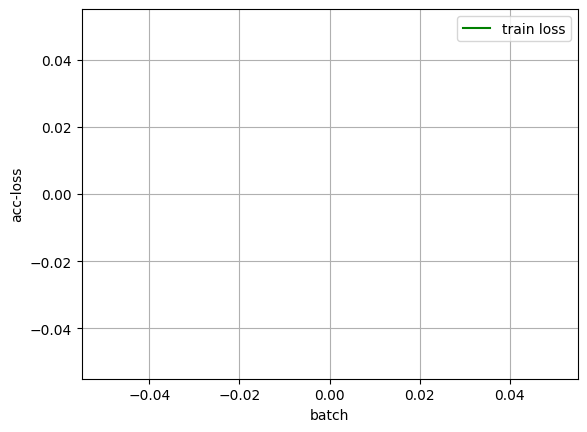

In [12]:
train_xception(
    num_classes=5, train_loader=train_loader, val_loader=validation_loader, epochs=1
)
# Plot results
history_this.loss_plot("epoch")
history_this.loss_plot("batch")  # If you also log batch-level metrics
plt.show()

Validation accuracy of Xception: 100.0%


### Model 3: VGG16


In [11]:
def train_vgg16(
    train_loader,
    val_loader,
    num_classes=5,
    epochs=1,
    save_path="./artifacts/vgg16.pth",
    freeze_until=15,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load pretrained VGG16
    model_fine_tune = models.vgg16(pretrained=True)

    # Freeze early layers
    for idx, param in enumerate(model_fine_tune.features.parameters()):
        if idx < freeze_until:
            param.requires_grad = False

    # Replace classifier head
    model_fine_tune.classifier = nn.Sequential(
        nn.Linear(25088, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(256, num_classes),
    )

    model = model_fine_tune.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / val_total

        history_this.record_epoch(train_loss, train_acc, val_loss, val_acc)

        print(
            f"[{epoch+1}/{epochs}] Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}"
        )

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)

    print(f"Best Validation Accuracy: {best_val_acc:.4f}")

[1/1] Train Loss: 1.6352, Acc: 0.8605 | Val Loss: 0.6303, Acc: 0.8544
Best Validation Accuracy: 0.8544


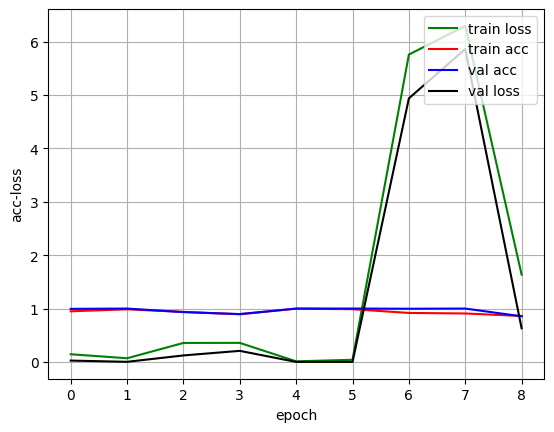

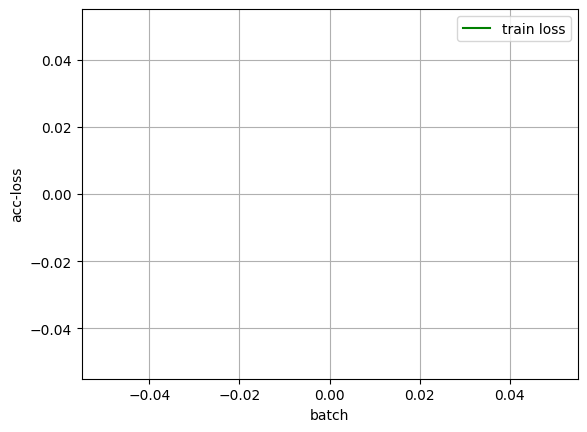

In [40]:
train_vgg16(
    num_classes=5, train_loader=train_loader, val_loader=validation_loader, epochs=1
)
# Plot results
history_this.loss_plot("epoch")
history_this.loss_plot("batch")  # If you also log batch-level metrics
plt.show()

Validation accuracy of VGG16: 100.0%


### Model 4: VGG19


In [12]:
def train_vgg19(
    num_classes,
    train_loader,
    val_loader,
    epochs=1,
    save_path="./artifacts/vgg19.pth",
    freeze_until=19,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load pretrained VGG19
    model_fine_tune = models.vgg19(pretrained=True)

    # Freeze early convolutional layers (based on number of conv layers)
    for idx, param in enumerate(model_fine_tune.features.parameters()):
        if idx < freeze_until:
            param.requires_grad = False

    # Replace classifier head
    model_fine_tune.classifier = nn.Sequential(
        nn.Linear(25088, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(256, num_classes),
    )

    model = model_fine_tune.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / total

        # Validation phase
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / val_total

        history_this.record_epoch(train_loss, train_acc, val_loss, val_acc)

        print(
            f"[{epoch+1}/{epochs}] Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}"
        )

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)

    print(f"Best Validation Accuracy: {best_val_acc:.4f}")

[1/1] Train Loss: 0.3568, Acc: 0.8923 | Val Loss: 0.2073, Acc: 0.8965
Best Validation Accuracy: 0.8965


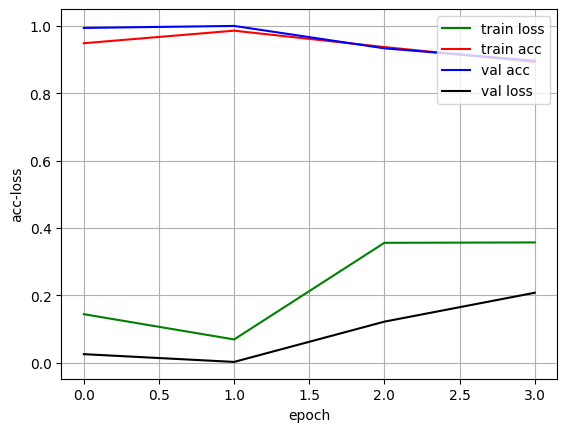

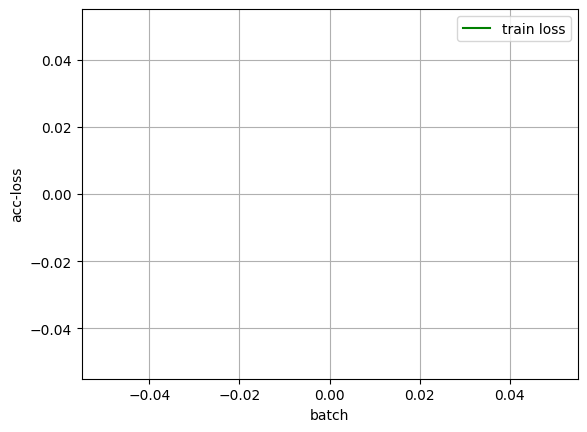

In [16]:
train_vgg19(
    num_classes=5, train_loader=train_loader, val_loader=validation_loader, epochs=1
)
history_this.loss_plot("epoch")
history_this.loss_plot("batch")
plt.show()

Validation accuracy of VGG19: 100.0%


### Model 5: ResNet


In [13]:
def train_resnet50(
    num_classes,
    train_loader,
    val_loader,
    epochs=1,
    save_path="./artifacts/resnet50.pth",
    freeze_until=120,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load pretrained ResNet50
    model_fine_tune = models.resnet50(pretrained=True)

    # Freeze first `freeze_until` layers (counted by named parameters)
    child_counter = 0
    for name, param in model_fine_tune.named_parameters():
        if child_counter < freeze_until:
            param.requires_grad = False
        else:
            param.requires_grad = True
        child_counter += 1

    # Replace final fully connected layer
    in_features = model_fine_tune.fc.in_features
    model_fine_tune.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(256, num_classes),
    )

    model = model_fine_tune.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            train_correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / val_total

        history_this.record_epoch(train_loss, train_acc, val_loss, val_acc)

        print(
            f"[{epoch+1}/{epochs}] Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}"
        )

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)

    print(f"Best Validation Accuracy: {best_val_acc:.4f}")

[1/1] Train Loss: 0.0109, Acc: 0.9969 | Val Loss: 0.0000, Acc: 1.0000
Best Validation Accuracy: 1.0000


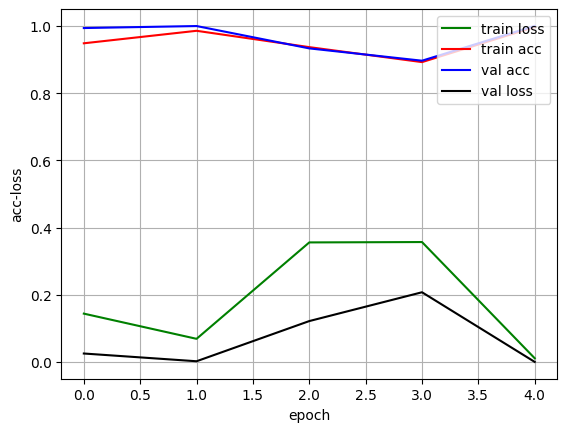

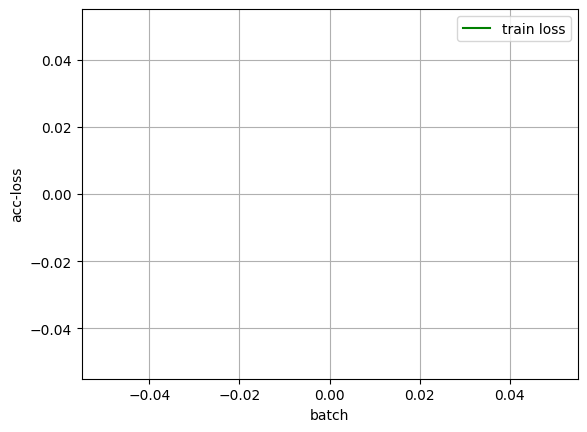

In [18]:
train_resnet50(
    num_classes=5, train_loader=train_loader, val_loader=validation_loader, epochs=1
)
history_this.loss_plot("epoch")
history_this.loss_plot("batch")
plt.show()

Validation accuracy of Resnet: 98.652%


### Model 6: Inception


In [14]:
def train_inception_v3(
    num_classes,
    train_loader,
    val_loader,
    epochs=1,
    save_path="./artifacts/inception_v3.pth",
    freeze_until=35,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load pretrained InceptionV3
    # model_fine_tune = models.inception_v3(
    #     pretrained=True, aux_logits=True
    # )  # aux_logits=False disables side branch

    model_fine_tune = models.inception_v3(weights=None, aux_logits=False)
    model_fine_tune = models.inception_v3(aux_logits=False)
    state_dict = models.inception_v3(weights="DEFAULT", aux_logits=True).state_dict()
    model_fine_tune.load_state_dict(state_dict, strict=False)

    # Freeze early layers
    child_counter = 0
    for name, param in model_fine_tune.named_parameters():
        if child_counter < freeze_until:
            param.requires_grad = False
        else:
            param.requires_grad = True
        child_counter += 1

    # Replace the final fully connected layer
    in_features = model_fine_tune.fc.in_features
    model_fine_tune.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(256, num_classes),
    )

    model = model_fine_tune.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            train_correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / total

        # Validation phase
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / val_total

        history_this.record_epoch(train_loss, train_acc, val_loss, val_acc)

        print(
            f"[{epoch+1}/{epochs}] Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}"
        )

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)

    print(f"Best Validation Accuracy: {best_val_acc:.4f}")

[1/1] Train Loss: 0.0403, Acc: 0.9878 | Val Loss: 0.0003, Acc: 0.9998
Best Validation Accuracy: 0.9998


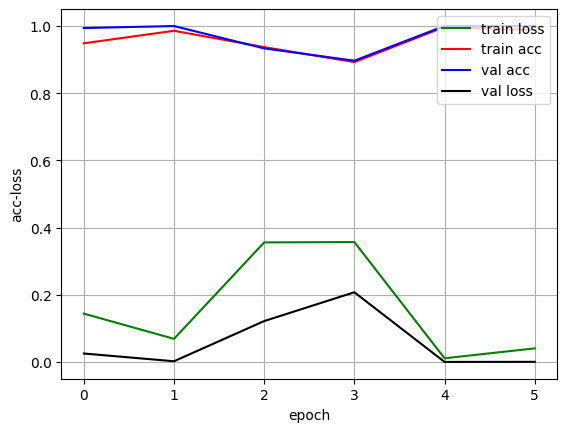

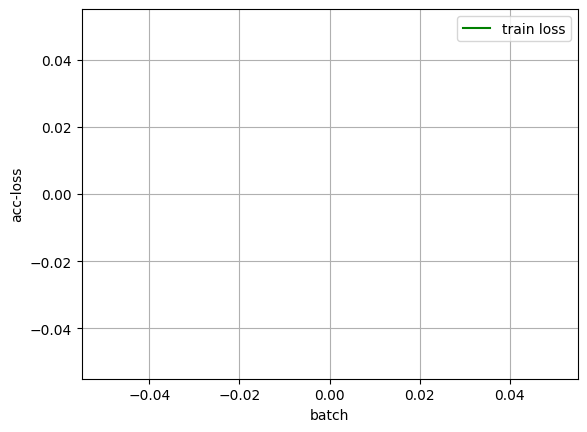

In [28]:
train_inception_v3(
    num_classes=5, train_loader=train_loader, val_loader=validation_loader, epochs=1
)
history_this.loss_plot("epoch")
history_this.loss_plot("batch")
plt.show()

Validation accuracy of Inception: 100.0%


### Model 7: InceptionResnet


In [15]:
import timm
import torch
import torch.nn as nn
import torch.optim as optim


def train_inceptionresnetv2(
    num_classes,
    train_loader,
    val_loader,
    epochs=5,
    save_path="./artifacts/inceptionresnetv2.pth",
    freeze_until=500,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # ─── Build model with a proper 1536→num_classes head ──────────────────────
    model = timm.create_model(
        "inception_resnet_v2",
        pretrained=True,
        num_classes=num_classes,  # ← sets final Linear(1536, num_classes)
        drop_rate=0.5,  # ← adds a dropout before the head
    )

    # ─── Freeze early layers by parameter index ───────────────────────────────
    for idx, (name, param) in enumerate(model.named_parameters()):
        param.requires_grad = idx >= freeze_until

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    # Only pass the unfrozen parameters to the optimizer
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2
    )

    best_val_acc = 0.0

    for epoch in range(1, epochs + 1):
        # ─── Training ──────────────────────────────────────────────────────────
        model.train()
        running_loss, running_corrects, running_total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_corrects += (preds == labels).sum().item()
            running_total += labels.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = running_corrects / running_total

        # ─── Validation ────────────────────────────────────────────────────────
        model.eval()
        val_loss, val_corrects, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                val_corrects += (preds == labels).sum().item()
                val_total += labels.size(0)

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = val_corrects / val_total

        scheduler.step(epoch_val_loss)
        history_this.record_epoch(
            epoch_train_loss, epoch_train_acc, epoch_val_loss, epoch_val_acc
        )

        print(
            f"[{epoch}/{epochs}] "
            f"Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.4f} | "
            f"Val   Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.4f}"
        )

        # ─── Save best ─────────────────────────────────────────────────────────
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), save_path)

    print(f"✅ Best Validation Accuracy: {best_val_acc:.4f}")

[1/1] Train Loss: 0.0284, Acc: 0.9942 | Val   Loss: 5.2188, Acc: 0.9620
✅ Best Validation Accuracy: 0.9620


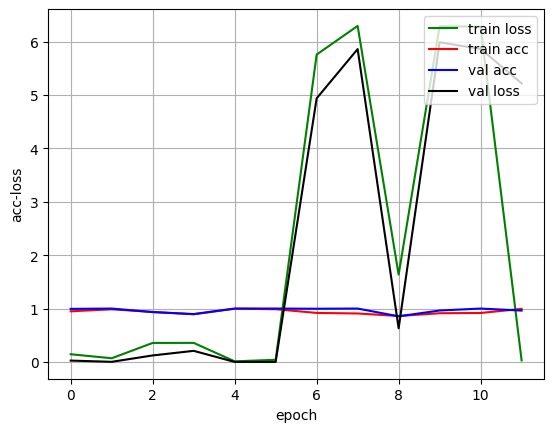

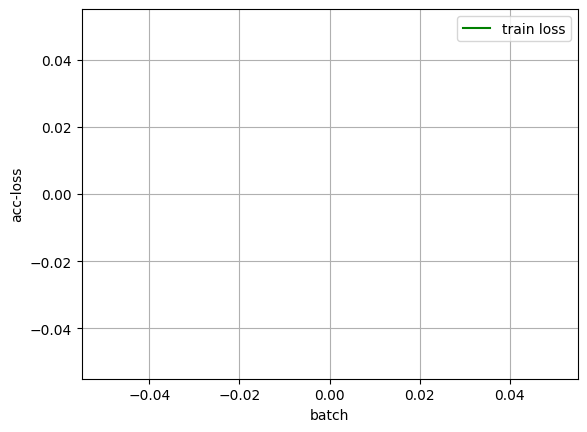

In [46]:
train_inceptionresnetv2(
    num_classes=5, train_loader=train_loader, val_loader=validation_loader, epochs=1
)
history_this.loss_plot("epoch")
history_this.loss_plot("batch")
plt.show()

Validation accuracy of InceptionResnet: 99.993%


# EXPERIMENTS - ViT


In [16]:
def train_vit(
    train_loader,
    val_loader,
    num_classes=5,
    epochs=10,
    freeze_until=None,
    save_path="./artifacts/vit.pth",
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load Vision Transformer model from timm
    model = timm.create_model(
        "vit_base_patch16_224", pretrained=True, num_classes=num_classes
    )

    if freeze_until:
        for i, (name, param) in enumerate(model.named_parameters()):
            if i < freeze_until:
                param.requires_grad = False

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=2)

    best_val_acc = 0
    # history = LossHistory()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / total
        train_acc = correct / total

        # Validation
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss /= val_total
        val_acc = val_correct / val_total
        # at end of epoch

        # history_this.record_epoch(train_loss, train_acc, val_loss, val_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] - "
            f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)

        scheduler.step(val_loss)

    print(f"✅ Best Validation Accuracy: {best_val_acc:.4f}")
    # history.loss_plot()

In [9]:
train_vit(
    train_loader=train_loader,
    val_loader=validation_loader,
    num_classes=5,
    epochs=1,
    save_path="./artifacts/vit.pth",
)
# print("Recorded train losses:", history_this.train_losses)
# print("Recorded train accs: ", history_this.train_accs)
# print("Recorded val   losses:", history_this.val_losses)
# print("Recorded val   accs: ", history_this.val_accs)

# history_this.loss_plot("epoch")
# history_this.loss_plot("batch")
# plt.xlim(1, 1)
# plt.ylim(0, 1)
# plt.show()

Epoch [1/1] - Train Loss: 0.0029, Acc: 0.9990 | Val Loss: 0.0000, Acc: 1.0000
✅ Best Validation Accuracy: 1.0000


# DEMO FUNCTIONs


In [17]:
# ✅ Demo Custom CNN
def run_demo_customcnn():
    print("\n🧪 Demo: Custom CNN")
    model = CustomCNN(num_classes=5)
    train_model(
        model,
        train_loader,
        validation_loader,
        num_classes=5,
        epochs=DEMO_EPOCHS,
        save_path="demo_models/demo_customcnn.pth",
    )
    history_this.plot()


# ✅ Demo VGG16
def run_demo_vgg16():
    print("\n🧪 Demo: VGG16")
    train_vgg16(
        num_classes=5,
        train_loader=train_loader,
        val_loader=validation_loader,
        epochs=DEMO_EPOCHS,
        freeze_until=15,
        save_path="demo_models/demo_vgg16.pth",
    )
    history_this.plot()


# ✅ Demo VGG19
def run_demo_vgg19():
    print("\n🧪 Demo: VGG19")
    train_vgg19(
        num_classes=5,
        train_loader=train_loader,
        val_loader=validation_loader,
        epochs=DEMO_EPOCHS,
        freeze_until=19,
        save_path="demo_models/demo_vgg19.pth",
    )
    history_this.plot()


# ✅ Demo ResNet50
def run_demo_resnet():
    print("\n🧪 Demo: ResNet50")
    train_resnet50(
        num_classes=5,
        train_loader=train_loader,
        val_loader=validation_loader,
        epochs=DEMO_EPOCHS,
        freeze_until=100,
        save_path="demo_models/demo_resnet.pth",
    )
    history_this.plot()


# ✅ Demo InceptionV3
def run_demo_inception():
    print("\n🧪 Demo: InceptionV3")
    train_inception_v3(
        num_classes=5,
        train_loader=train_loader,
        val_loader=validation_loader,
        epochs=DEMO_EPOCHS,
        freeze_until=30,
        save_path="demo_models/demo_inception.pth",
    )
    history_this.plot()


# ✅ Demo Xception
def run_demo_xception():
    print("\n🧪 Demo: Xception")
    train_xception(
        num_classes=5,
        train_loader=train_loader,
        val_loader=validation_loader,
        epochs=DEMO_EPOCHS,
        save_path="demo_models/demo_xception.pth",
    )
    history_this.plot()


# ✅ Demo InceptionResNetV2
def run_demo_inceptionresnet():
    print("\n🧪 Demo: InceptionResNetV2")
    train_inceptionresnetv2(
        num_classes=5,
        train_loader=train_loader,
        val_loader=validation_loader,
        epochs=DEMO_EPOCHS,
        freeze_until=400,
        save_path="demo_models/demo_incepres.pth",
    )
    history_this.plot()


# ✅ Demo Vision Transformer
def run_demo_vit():
    print("\n🧪 Demo: Vision Transformer")
    train_vit(
        train_loader=train_loader,
        val_loader=validation_loader,
        num_classes=5,
        epochs=DEMO_EPOCHS,
        freeze_until=100,
        save_path="demo_models/demo_vit.pth",
    )
    history_this.plot()

In [18]:
def run_all_model_demos():
    print("🚀 Running quick demo for all models (in demo mode)")
    print("=" * 60)

    try:
        print("\n🔹 1. Custom CNN")
        run_demo_customcnn()
    except Exception as e:
        print("❌ CustomCNN failed:", e)

    try:
        print("\n🔹 2. VGG16")
        run_demo_vgg16()
    except Exception as e:
        print("❌ VGG16 failed:", e)

    try:
        print("\n🔹 3. VGG19")
        run_demo_vgg19()
    except Exception as e:
        print("❌ VGG19 failed:", e)

    try:
        print("\n🔹 4. ResNet50")
        run_demo_resnet()
    except Exception as e:
        print("❌ ResNet50 failed:", e)

    try:
        print("\n🔹 5. InceptionV3")
        run_demo_inception()
    except Exception as e:
        print("❌ InceptionV3 failed:", e)

    try:
        print("\n🔹 6. Xception")
        run_demo_xception()
    except Exception as e:
        print("❌ Xception failed:", e)

    try:
        print("\n🔹 7. InceptionResNetV2")
        run_demo_inceptionresnet()
    except Exception as e:
        print("❌ InceptionResNetV2 failed:", e)

    print("\n✅ All model demos complete.")
    print("=" * 60)

🚀 Running quick demo for all models (in demo mode)

🔹 1. Custom CNN

🧪 Demo: Custom CNN
Epoch [1/3] - Train Loss: 0.5753, Train Acc: 0.7734 | Val Loss: 0.0000, Val Acc: 1.0000
Epoch [2/3] - Train Loss: 0.0000, Train Acc: 1.0000 | Val Loss: 0.0000, Val Acc: 1.0000
Epoch [3/3] - Train Loss: 0.0000, Train Acc: 1.0000 | Val Loss: 0.0000, Val Acc: 1.0000
Best Validation Accuracy: 1.0000


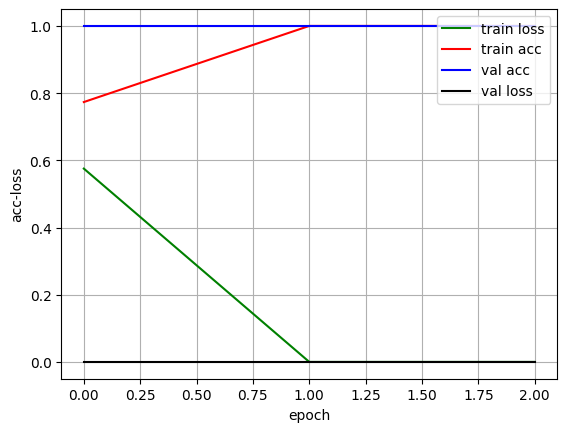


🔹 2. VGG16

🧪 Demo: VGG16
[1/3] Train Loss: 0.1980, Acc: 0.9062 | Val Loss: 0.0000, Acc: 1.0000
[2/3] Train Loss: 0.0000, Acc: 1.0000 | Val Loss: 0.0000, Acc: 1.0000
[3/3] Train Loss: 0.0000, Acc: 1.0000 | Val Loss: 0.0000, Acc: 1.0000
Best Validation Accuracy: 1.0000


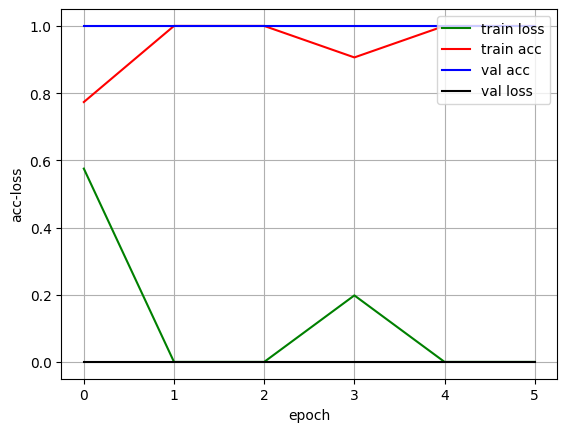


🔹 3. VGG19

🧪 Demo: VGG19
[1/3] Train Loss: 0.2196, Acc: 0.8750 | Val Loss: 0.0000, Acc: 1.0000
[2/3] Train Loss: 0.0000, Acc: 1.0000 | Val Loss: 0.0000, Acc: 1.0000
[3/3] Train Loss: 0.0000, Acc: 1.0000 | Val Loss: 0.0000, Acc: 1.0000
Best Validation Accuracy: 1.0000


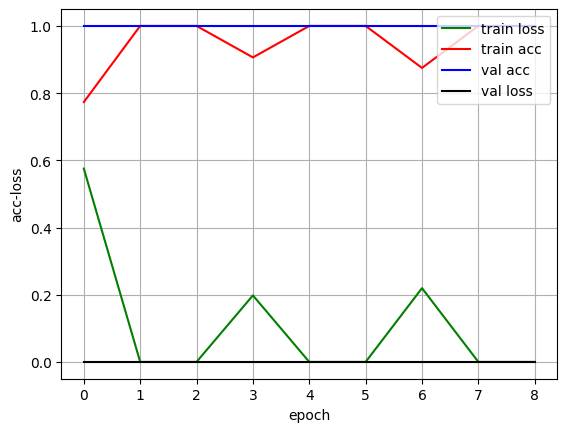


🔹 4. ResNet50

🧪 Demo: ResNet50
[1/3] Train Loss: 0.2336, Acc: 0.8750 | Val Loss: 0.0000, Acc: 1.0000
[2/3] Train Loss: 0.0000, Acc: 1.0000 | Val Loss: 0.0000, Acc: 1.0000
[3/3] Train Loss: 0.0000, Acc: 1.0000 | Val Loss: 0.0000, Acc: 1.0000
Best Validation Accuracy: 1.0000


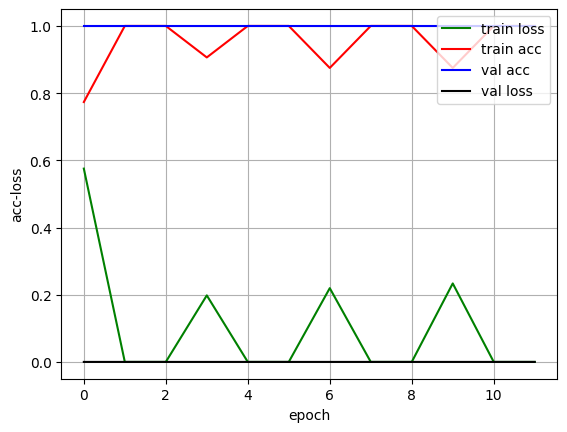


🔹 5. InceptionV3

🧪 Demo: InceptionV3
[1/3] Train Loss: 0.2238, Acc: 0.9531 | Val Loss: 0.0000, Acc: 1.0000
[2/3] Train Loss: 0.0000, Acc: 1.0000 | Val Loss: 0.0000, Acc: 1.0000
[3/3] Train Loss: 0.0000, Acc: 1.0000 | Val Loss: 0.0000, Acc: 1.0000
Best Validation Accuracy: 1.0000


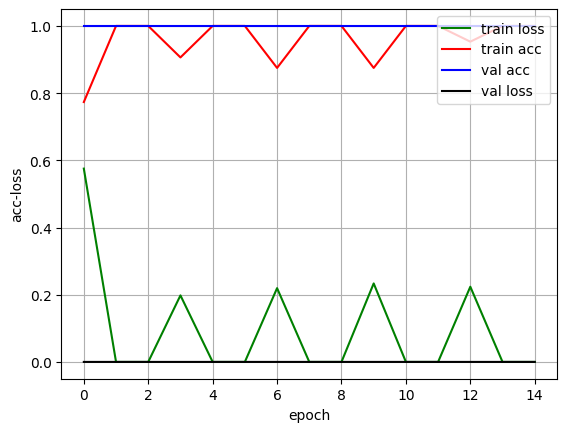


🔹 6. Xception

🧪 Demo: Xception
[1/3] Train Loss: 0.6359, Acc: 0.9062 | Val Loss: 0.2278, Acc: 1.0000
[2/3] Train Loss: 0.0617, Acc: 1.0000 | Val Loss: 0.0638, Acc: 1.0000
[3/3] Train Loss: 0.0221, Acc: 1.0000 | Val Loss: 0.0165, Acc: 1.0000
Best Validation Accuracy: 1.0000


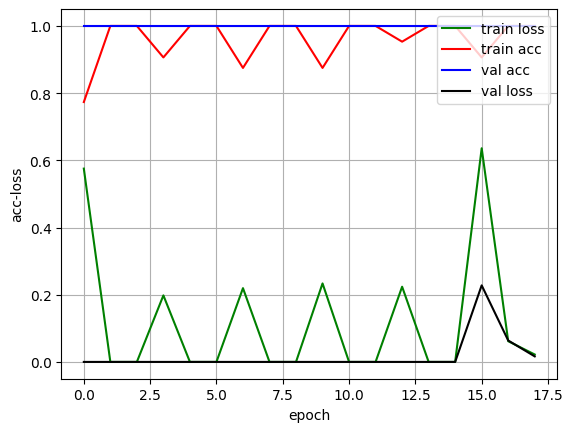


🔹 7. InceptionResNetV2

🧪 Demo: InceptionResNetV2
[1/3] Train Loss: 1.2705, Acc: 0.7344 | Val   Loss: 1.5284, Acc: 0.4141
[2/3] Train Loss: 0.6820, Acc: 0.9922 | Val   Loss: 1.1543, Acc: 0.9922
[3/3] Train Loss: 0.3040, Acc: 1.0000 | Val   Loss: 0.3245, Acc: 1.0000
✅ Best Validation Accuracy: 1.0000


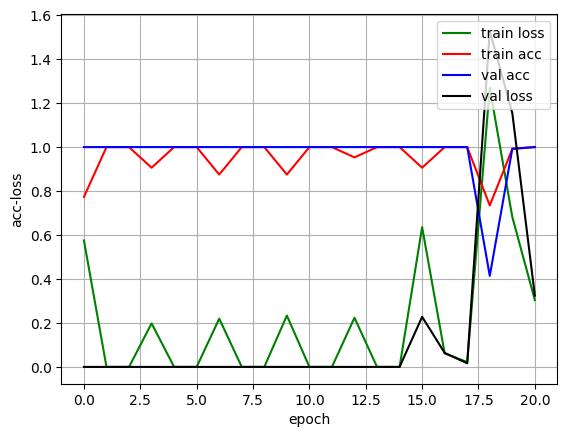


✅ All model demos complete.


In [25]:
if DEMO_MODE:
    run_all_model_demos()